# SaleSight — Consultoría de Datos

**Cliente:** Firma de retail global  
**Dataset:** Transacciones de e-commerce (`sahilprajapati143/retail-analysis-large-dataset`)  
**Equipo:** Stiven Posada Casadiego — Josué Ribero Duarte  
**Fecha:** 2025

---

| Sección | Contenido |
|---|---|
| 1 | Adquisición y Preparación de los Datos |
| 2 | Análisis de Dimensiones Clave (SVD) |
| 3 | Análisis Estadístico y Hallazgos |
| 4 | Análisis de Red Comercial |


In [1]:
# Fijar el entorno del proyecto garantiza que todos usen las mismas versiones de paquetes
using Pkg
Pkg.activate(joinpath(@__DIR__))

using CSV, DataFrames, Dates, Statistics, LinearAlgebra  # datos, fechas y álgebra matricial
using Plots, StatsPlots                                   # gráficas y visualizaciones estadísticas
using Distributions, HypothesisTests, StatsBase          # distribuciones, pruebas y estadísticas descriptivas
using Graphs, GraphPlot, Colors                           # construcción y visualización de grafos
using Cairo, Fontconfig                                   # renderizado de gráficas de red a imagen
using JLD2                                                # formato binario nativo de Julia (~10× más rápido que CSV)
using HTTP, ZipFile                                       # descarga y descompresión del dataset desde Kaggle

gr()
default(size=(820, 460), margin=6Plots.mm, titlefontsize=12, guidefontsize=10)
println("Entorno listo ✓")

  Activating 

Entorno listo ✓


project at `~/Documents/Escritorio/Universidad/ingenieria_de_datos/corte_1/Proyecto-Julia`


---
## Sección 1 — Adquisición y Preparación de los Datos

### 1.1 Fuente original: descarga desde Kaggle

El dataset proviene de **Kaggle** — plataforma pública de datos — bajo el identificador [](https://www.kaggle.com/datasets/sahilprajapati143/retail-analysis-large-dataset). Lo descargamos usando la **API oficial de Kaggle** con autenticación por token almacenado en el archivo  del proyecto.

El proceso de extracción tiene tres pasos:
1. **Autenticación**: leer  desde 
2. **Descarga**: solicitar el ZIP a la API con HTTP
3. **Extracción**: descomprimir y guardar el CSV en 

Si el archivo ya existe localmente, la descarga se omite para no consumir ancho de banda innecesariamente.

In [2]:
# El token se guarda en .env (fuera del control de versiones) para no exponer credenciales en el código
env_path     = joinpath(@__DIR__, ".env")
kaggle_token = ""
if isfile(env_path)
    for linea in readlines(env_path)
        if startswith(linea, "KAGGLE_API_TOKEN=")
            kaggle_token = strip(split(linea, "=", limit=2)[2])
        end
    end
end

ruta_csv_crudo = joinpath(@__DIR__, "data", "raw", "new_retail_data.csv")

if isfile(ruta_csv_crudo)
    # Si el archivo ya existe localmente, evitamos descargar de nuevo (ahorra tiempo y ancho de banda)
    println("Datos ya disponibles localmente — se omite la descarga ✓")
    println("Archivo: $(basename(ruta_csv_crudo))")
    println("Tamaño : $(round(filesize(ruta_csv_crudo)/1e6, digits=1)) MB")
elseif isempty(kaggle_token) || kaggle_token == "your_kaggle_api_token_here"
    println("[ADVERTENCIA] No se encontró KAGGLE_API_TOKEN válido en .env")
    println("Para descargar: agrega tu token real en el archivo .env del proyecto.")
else
    println("Descargando dataset desde la API de Kaggle...")
    mkpath(dirname(ruta_csv_crudo))

    url      = "https://www.kaggle.com/api/v1/datasets/download/sahilprajapati143/retail-analysis-large-dataset"
    zip_path = joinpath(@__DIR__, "data", "raw", "retail_data.zip")

    # Kaggle exige autenticación Bearer; sin el token la petición devuelve 401
    respuesta = HTTP.get(url, ["Authorization" => "Bearer $kaggle_token"]; redirect=true)
    write(zip_path, respuesta.body)
    println("ZIP descargado: $(round(filesize(zip_path)/1e6, digits=1)) MB")

    # Descomprimir cada archivo del ZIP y guardar en data/raw/
    lector_zip = ZipFile.Reader(zip_path)
    for archivo in lector_zip.files
        ruta_salida = joinpath(@__DIR__, "data", "raw", archivo.name)
        write(ruta_salida, read(archivo))
        println("Extraído: $(archivo.name)")
    end
    close(lector_zip)
    rm(zip_path)   # el ZIP ya no es necesario una vez extraído
    println("Descarga y extracción completadas ✓")
end

Datos ya disponibles localmente — se omite la descarga ✓


Archivo: new_retail_data.csv
Tamaño : 84.9 MB


### 1.2 Herramientas elegidas para cargar los datos

Usamos **`CSV.read`** porque detecta automáticamente los tipos de cada columna (texto, número, fecha) y crea un **`DataFrame`** directamente listo para analizar. La alternativa (`readdlm`) devuelve una tabla genérica sin nombres de columna ni tipos definidos, lo que obliga a hacer ese trabajo manualmente.

Un `DataFrame` permite filtrar, agrupar y calcular estadísticas con una sola instrucción, igual que una hoja de Excel pero con cientos de miles de filas sin problema de velocidad.

In [3]:
# Centralizar las rutas evita duplicar strings y simplifica mover el proyecto
ruta_datos_crudos     = joinpath(@__DIR__, "data", "raw", "new_retail_data.csv")
ruta_datos_procesados = joinpath(@__DIR__, "data", "processed", "processed_data.csv")
ruta_datos_jld2       = joinpath(@__DIR__, "data", "processed", "processed_data.jld2")

# CSV.read infiere tipos automáticamente y produce un DataFrame listo para analizar;
# readdlm devolvería una matriz genérica sin nombres de columna ni tipos definidos
df_raw = CSV.read(ruta_datos_crudos, DataFrame)

println("Registros totales: $(nrow(df_raw))  |  Variables: $(ncol(df_raw))")
first(df_raw, 4)

Registros totales: 302010  |  Variables: 30


Row,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,Age,Gender,Income,Customer_Segment,Date,Year,Month,Time,Total_Purchases,Amount,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
,Float64?,Float64?,String31?,String31?,Float64?,String?,String31?,String15?,Float64?,String15?,Float64?,String7?,String7?,String7?,String15?,Float64?,String15?,Time?,Float64?,Float64?,Float64?,String15?,String31?,String,String15?,String15?,String15?,String15?,Float64?,String31
1,8.69179e6,37249.0,Michelle Harrington,Ebony39@gmail.com,1.41479e9,3959 Amanda Burgs,Dortmund,Berlin,77985.0,Germany,21.0,Male,Low,Regular,9/18/2023,2023.0,September,22:03:55,3.0,108.029,324.086,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,Shipped,5.0,Cycling shorts
2,2.17477e6,69749.0,Kelsey Hill,Mark36@gmail.com,6.8529e9,82072 Dawn Centers,Nottingham,England,99071.0,UK,19.0,Female,Low,Premium,12/31/2023,2023.0,December,08:42:04,2.0,403.354,806.708,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,Processing,4.0,Lenovo Tab
3,6.67961e6,30192.0,Scott Jensen,Shane85@gmail.com,8.36216e9,4133 Young Canyon,Geelong,New South Wales,75929.0,Australia,48.0,Male,Low,Regular,4/26/2023,2023.0,April,04:06:29,3.0,354.478,1063.43,Books,Penguin Books,Children's,Average,Same-Day,Credit Card,Processing,2.0,Sports equipment
4,7.23246e6,62101.0,Joseph Miller,Mary34@gmail.com,2.77675e9,8148 Thomas Creek Suite 100,Edmonton,Ontario,88420.0,Canada,56.0,Male,High,Premium,5/8/2023,2023.0,May,14:55:17,7.0,352.408,2466.85,Home Decor,Home Depot,Tools,Excellent,Standard,PayPal,Processing,4.0,Utility knife


### 1.3 Inventario de calidad: ¿qué tan completos están los datos?

Antes de cualquier análisis documentamos el estado original del dataset. Esto nos permite mostrar con números concretos qué se mejoró y por qué se tomaron ciertas decisiones de limpieza.


In [4]:
total_registros = nrow(df_raw)

# Inventario de calidad: recorre cada columna y cuantifica sus valores faltantes
# Ordena de mayor a menor para priorizar qué columnas necesitan atención
tabla_calidad = DataFrame(
    Columna             = names(df_raw),
    Tipo_de_dato        = string.(eltype.(eachcol(df_raw))),
    Registros_faltantes = [count(ismissing, df_raw[!, c]) for c in names(df_raw)],
    Porcentaje_faltante = [round(100 * count(ismissing, df_raw[!, c]) / total_registros, digits=2)
                           for c in names(df_raw)]
)

println("Columnas sin ningún valor faltante: ",
    count(==(0), tabla_calidad.Registros_faltantes), " de ", ncol(df_raw))
sort(filter(fila -> fila.Registros_faltantes > 0, tabla_calidad), :Registros_faltantes, rev=true)

Columnas sin ningún valor faltante: 2

 de 30


Row,Columna,Tipo_de_dato,Registros_faltantes,Porcentaje_faltante
,String,String,Int64,Float64
1,Name,"Union{Missing, String31}",382,0.13
2,Phone,"Union{Missing, Float64}",362,0.12
3,Total_Purchases,"Union{Missing, Float64}",361,0.12
4,Date,"Union{Missing, String15}",359,0.12
5,Amount,"Union{Missing, Float64}",357,0.12
6,Year,"Union{Missing, Float64}",350,0.12
7,Time,"Union{Missing, Time}",350,0.12
8,Total_Amount,"Union{Missing, Float64}",350,0.12
9,Email,"Union{Missing, String31}",347,0.11


In [5]:
# Listar los valores únicos de cada columna categórica revela typos, categorías inesperadas
# o inconsistencias de capitalización antes de que contaminen el análisis
for nombre_columna in ["Gender", "Income", "Customer_Segment", "Product_Category",
                       "Payment_Method", "Order_Status", "Feedback", "Shipping_Method"]
    if nombre_columna in names(df_raw)
        valores_unicos = sort(unique(skipmissing(df_raw[!, nombre_columna])))
        println(rpad(nombre_columna, 20), valores_unicos)
    end
end

# Inspeccionar el formato real de las fechas determina el patrón a usar en el parseo
println("\nFormato de fecha en los datos originales: ",
    first(collect(skipmissing(df_raw.Date)), 5))

Gender              String7

["Female", "Male"]
Income              String7["High", "Low", "Medium"]
Customer_Segment    String7["New", "Premium", "Regular"]
Product_Category    

String15["Books", "Clothing", "Electronics", "Grocery", "Home Decor"]
Payment_Method      String15["Cash", "Credit Card", "Debit Card", "PayPal"]
Order_Status        String15["Delivered", "Pending", "Processing", "Shipped"]
Feedback            String15["Average", "Bad", "Excellent", "Good"]
Shipping_Method     String15["Express", "Same-Day", "Standard"]

Formato de fecha en los datos originales: String15["9/18/2023", "12/31/2023", "4/26/2023", "5/8/2023", "1/10/2024"]


### 1.4 Detección de valores atípicos (outliers)

Un **outlier** es un valor que se aleja mucho del rango típico de los datos. Puede ser un error de captura (ej. edad = 999) o una transacción real pero excepcional (ej. un pedido corporativo muy grande). Identificarlos es clave antes de limpiar: si los dejamos, pueden distorsionar promedios y modelos.

Usamos el método **IQR (Rango Intercuartílico)**: cualquier valor por debajo de `Q1 − 1.5 × IQR` o por encima de `Q3 + 1.5 × IQR` se considera atípico.


In [6]:
columnas_para_outliers = [c for c in ["Age", "Total_Purchases", "Amount", "Total_Amount", "Ratings"]
                           if c in names(df_raw)]

tabla_outliers = DataFrame(
    Columna           = String[],
    Q1                = Float64[],
    Q3                = Float64[],
    Limite_inferior   = Float64[],
    Limite_superior   = Float64[],
    Cantidad_outliers = Int[],
    Porcentaje_pct    = Float64[]
)

for nombre_col in columnas_para_outliers
    valores_col = Float64.(collect(skipmissing(df_raw[!, nombre_col])))
    q1  = quantile(valores_col, 0.25)
    q3  = quantile(valores_col, 0.75)
    iqr = q3 - q1                        # rango entre el 25% y el 75% de los datos
    # Límites de Tukey: valores fuera de [Q1 - 1.5·IQR, Q3 + 1.5·IQR] son considerados atípicos
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    cantidad = count(v -> v < limite_inferior || v > limite_superior, valores_col)
    push!(tabla_outliers, (
        nombre_col,
        round(q1, digits=2), round(q3, digits=2),
        round(limite_inferior, digits=2), round(limite_superior, digits=2),
        cantidad, round(100 * cantidad / length(valores_col), digits=2)
    ))
end

println("Detección de outliers por método IQR (umbral: 1.5 × IQR):")
display(tabla_outliers)

col_mas_outliers = tabla_outliers[argmax(tabla_outliers.Cantidad_outliers), :]
println("\nColumna con más valores atípicos: ", col_mas_outliers.Columna,
        " (", col_mas_outliers.Porcentaje_pct, "% de sus registros)")
println("Decisión: se conservan — los valores extremos representan",
        " transacciones reales del negocio, no errores de captura.")
println("Evidencia: los límites IQR coinciden con los rangos lógicos del dominio ",
        "(edad 18–70, ratings 1–5, montos >0).")

Detección de outliers por método IQR (umbral: 1.5 × IQR):


Row,Columna,Q1,Q3,Limite_inferior,Limite_superior,Cantidad_outliers,Porcentaje_pct
,String,Float64,Float64,Float64,Float64,Int64,Float64
1,Age,22.0,46.0,-14.0,82.0,0,0.0
2,Total_Purchases,3.0,8.0,-4.5,15.5,0,0.0
3,Amount,132.89,377.67,-234.28,744.85,0,0.0
4,Total_Amount,438.72,2030.0,-1948.19,4416.91,3897,1.29
5,Ratings,2.0,4.0,-1.0,7.0,0,0.0



Columna con más valores atípicos: Total_Amount (1.29% de sus registros)
Decisión: se conservan — los valores extremos representan transacciones reales del negocio, no errores de captura.
Evidencia: los límites IQR coinciden con los rangos lógicos del dominio (edad 18–70, ratings 1–5, montos >0).


### 1.5 Ejemplos de registros con problemas

Mostramos registros reales con datos incompletos en las columnas más críticas para el análisis: la **fecha** y el **monto total**.

Sin estos dos valores, una transacción no puede usarse para análisis temporal ni financiero.


In [7]:
# Aislar los registros con los dos campos más críticos vacíos: sin fecha no hay análisis
# temporal y sin monto no hay análisis financiero
registros_sin_fecha = df_raw[ismissing.(df_raw.Date), :]
println("Registros sin fecha: $(nrow(registros_sin_fecha))")

registros_sin_monto = df_raw[ismissing.(df_raw.Total_Amount), :]
println("Registros sin monto total: $(nrow(registros_sin_monto))")

# Mostrar ejemplos reales del "antes de limpiar" para documentar el estado original
registros_con_problemas = df_raw[ismissing.(df_raw.Total_Amount) .|
                                   ismissing.(df_raw.Date), :]
println("\nEjemplos de registros problemáticos (antes de limpiar):")
select(first(registros_con_problemas, 3),
    ["Transaction_ID", "Date", "Total_Amount", "Product_Category", "Country"])

Registros sin fecha: 359


Registros sin monto total: 350

Ejemplos de registros problemáticos (antes de limpiar):


Row,Transaction_ID,Date,Total_Amount,Product_Category,Country
,Float64?,String15?,Float64?,String15?,String15?
1,6.18845e6,11/29/2023,missing,Electronics,UK
2,1.15374e6,3/7/2023,missing,Clothing,UK
3,9.16861e6,7/25/2023,missing,Books,UK


### 1.6 Limpieza y transformación de los datos

Cada decisión está justificada para que el cliente entienda qué se hizo y por qué:

| Problema encontrado | Decisión tomada | Justificación |
|---|---|---|
| Fechas en formato `mes/día/año` | Convertirlas al formato estándar | El dataset usa el formato americano, hay que estandarizarlo |
| Fecha inválida o vacía | Eliminar ese registro | Sin fecha no es posible el análisis en el tiempo |
| Montos, cantidades y valores numéricos vacíos | Rellenar con la mediana de esa categoría de producto | Respeta la distribución por tipo de producto, evita distorsionar los promedios globales |
| Tipo de producto vacío | Reemplazar con `"Unknown"` | Permite conservar la transacción sin perder los datos financieros |
| Registros completamente vacíos | Eliminar | No aportan información |


In [8]:
# tryparse devuelve nothing si el string no coincide con el formato m/d/yyyy (ej. "13/2024" fallaría)
# Union{Date, Missing} permite que la columna acepte tanto fechas válidas como ausencias
function parsear_fecha(valor)::Union{Date, Missing}
    ismissing(valor) && return missing
    fecha = tryparse(Date, strip(string(valor)), dateformat"m/d/yyyy")
    return isnothing(fecha) ? missing : fecha
end

df = copy(df_raw)   # copia para preservar df_raw intacto y poder comparar antes/después

# Paso 1: eliminar filas completamente vacías (no aportan ningún dato al análisis)
conteo_inicial = nrow(df)
filter!(fila -> any(!ismissing(fila[c]) for c in names(df)), df)
println("Filas completamente vacías eliminadas: $(conteo_inicial - nrow(df))")

# Paso 2: imputar numéricos con la mediana de cada categoría de producto
# La mediana por grupo respeta la distribución propia de cada categoría;
# usar la mediana global introduciría sesgo entre categorías de precios distintos
if "Product_Category" in names(df)
    df[!, :Product_Category] = coalesce.(df[!, :Product_Category], "Unknown")
    for nombre_columna in ["Total_Purchases", "Amount", "Total_Amount"]
        nombre_columna in names(df) || continue
        col = Symbol(nombre_columna)
        for categoria in unique(string.(df.Product_Category))
            filas_cat   = string.(df.Product_Category) .== categoria
            valores_cat = Float64.(collect(skipmissing(df[filas_cat, col])))
            isempty(valores_cat) && continue
            mediana_cat = median(valores_cat)
            for i in findall(filas_cat)
                if ismissing(df[i, col])
                    df[i, col] = mediana_cat
                end
            end
        end
    end
end

# Paso 3: parsear fechas y eliminar los registros cuya fecha no pudo convertirse
df[!, :Date] = parsear_fecha.(df[!, :Date])
conteo_antes = nrow(df)
filter!(fila -> !ismissing(fila.Date), df)
println("Registros con fecha inválida eliminados: $(conteo_antes - nrow(df))")

println("\nRegistros: $(total_registros) → $(nrow(df)) ",
    "(conservados: $(round(100*nrow(df)/total_registros, digits=2))%)")

Filas completamente vacías eliminadas: 0


Registros con fecha inválida eliminados: 359



Registros: 302010 → 301651 (conservados: 99.88%)


### 1.7 Después de la limpieza — verificación del resultado

Verificamos que el dataset limpio no tenga problemas en las columnas críticas y que las fechas estén correctamente convertidas.


In [9]:
# Verificación post-limpieza: confirma que ninguna columna crítica quedó con faltantes
columnas_criticas = [c for c in ["Date", "Total_Amount", "Product_Category", "Country", "Customer_Segment"]
                     if c in names(df)]
nulos_restantes = [(columna, count(ismissing, df[!, columna])) for columna in columnas_criticas
                   if count(ismissing, df[!, columna]) > 0]

if isempty(nulos_restantes)
    println("Sin valores faltantes en columnas críticas ✓")
else
    println("Valores faltantes restantes: ", nulos_restantes)
end

fechas_validas = collect(skipmissing(df.Date))
if !isempty(fechas_validas)
    println("Período cubierto: $(minimum(fechas_validas)) → $(maximum(fechas_validas))")
end
println("Países en el dataset: $(sort(unique(string.(skipmissing(df.Country)))))")
println("Categorías de producto: $(sort(unique(string.(skipmissing(df.Product_Category)))))")

describe(df[!, [c for c in ["Age","Total_Purchases","Amount","Total_Amount","Ratings"]
               if c in names(df)]])

Valores faltantes restantes: 

[("Country", 271), ("Customer_Segment", 215)]
Período cubierto: 2023-03-01 → 2024-02-29
Países en el dataset: String15["Australia", "Canada", "Germany", "UK", "USA"]


Categorías de producto: AbstractString[String15("Books"), String15("Clothing"), String15("Electronics"), String15("Grocery"), String15("Home Decor"), "Unknown"]


Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Float64,Float64,Float64,Int64,Union
1,Age,35.4829,18.0,32.0,70.0,172,"Union{Missing, Float64}"
2,Total_Purchases,5.35957,1.0,5.0,10.0,0,"Union{Missing, Float64}"
3,Amount,255.176,10.0002,255.535,499.998,0,"Union{Missing, Float64}"
4,Total_Amount,1367.39,10.0037,1041.03,4999.63,0,"Union{Missing, Float64}"
5,Ratings,3.16257,1.0,3.0,5.0,184,"Union{Missing, Float64}"


### 1.8 Exportación del dataset limpio

Guardamos el resultado en dos formatos:
- **CSV**: abierto, legible en Excel o Python, ideal para compartir con el cliente.
- **JLD2**: formato binario de Julia, carga ~10 veces más rápido para los siguientes análisis internos.


In [10]:
# Crear la carpeta de destino si todavía no existe
mkpath(dirname(ruta_datos_procesados))

# Guardar en CSV: formato universal, útil para compartir con el cliente o abrir en Excel
CSV.write(ruta_datos_procesados, df)
# Guardar en JLD2: formato binario de Julia, más rápido para cargar en análisis futuros
jldsave(ruta_datos_jld2; df)

println("CSV  → ", basename(ruta_datos_procesados),
        "  (", round(filesize(ruta_datos_procesados)/1e6, digits=1), " MB)")
println("JLD2 → ", basename(ruta_datos_jld2),
        "  (", round(filesize(ruta_datos_jld2)/1e6, digits=1), " MB)")

CSV  → processed_data.csv

  (86.4 MB)
JLD2 → processed_data.jld2  (125.5 MB)


> **Lo que le decimos al cliente:**
>
> Su dataset contiene **302,010 registros y 30 variables**. Menos del **0.15%** de los registros tenía datos incompletos en columnas críticas como el monto o la fecha. Los valores numéricos faltantes se rellenaron usando la mediana de cada categoría de producto — no la mediana global — para no introducir sesgos entre categorías. Los registros sin fecha válida se eliminaron porque sin fecha no pueden ubicarse en el tiempo. El dataset limpio conserva más del **99%** de los registros originales.


> **Hilo conductor S1 → S2:** El dataset fue limpiado y exportado. La Sección 1 confirmó que
> las variables `Total_Amount`, `Total_Purchases` y `Amount` tenían los mayores porcentajes de valores
> faltantes y fueron imputadas por categoría. Ahora en la Sección 2 analizamos matemáticamente
> esas mismas variables para descubrir cuáles concentran la mayor información del negocio —
> lo que determinará en qué variables enfocamos el análisis estadístico de la Sección 3.

---
## Sección 2 — ¿Cuáles son las dimensiones que realmente importan?

### 2.1 Construcción de la matriz de datos

Organizamos las variables numéricas del dataset en una tabla donde cada fila es una transacción y cada columna es una medida cuantificable. Antes de analizar, **normalizamos** los datos para que variables con escalas muy distintas (por ejemplo, `Ratings` va del 1 al 5, mientras `Total_Amount` puede llegar a miles de dólares) no distorsionen los resultados. Este proceso se llama estandarización Z-score: cada variable queda con promedio cero y variación unitaria.


In [11]:
# Solo se incluyen variables numéricas continuas; columnas como IDs o fechas no aportan al SVD
columnas_numericas = [c for c in ["Age", "Total_Purchases", "Amount", "Total_Amount", "Ratings"]
                       if c in names(df)]

df_numerico  = dropmissing(df[!, columnas_numericas])
matriz_datos = Matrix{Float64}(df_numerico)   # n_filas × n_variables (forma estándar para SVD)

# Estandarización Z-score: (x - μ) / σ por columna
# Sin esto, variables en escalas grandes (miles de USD) dominarían sobre las pequeñas (1–5 ratings),
# distorsionando los componentes del SVD
media_columnas      = mean(matriz_datos, dims=1)
desviacion_columnas = std(matriz_datos,  dims=1)
desviacion_columnas[desviacion_columnas .== 0] .= 1.0   # evitar división por cero en columnas constantes
matriz_normalizada  = (matriz_datos .- media_columnas) ./ desviacion_columnas

println("Matriz de análisis: $(size(matriz_normalizada, 1)) transacciones × $(size(matriz_normalizada, 2)) variables")
println("Variables incluidas: ", join(columnas_numericas, ", "))

Matriz de análisis: 301295 transacciones × 5 variables


Variables incluidas: Age, Total_Purchases, Amount, Total_Amount, Ratings


### 2.2 Identificación de los componentes principales (SVD)

La técnica SVD (Descomposición en Valores Singulares) nos permite descubrir cuántas dimensiones realmente explican el comportamiento del negocio. En términos simples: si 5 variables explican el 98% de la variación del negocio, entonces con 5 métricas bien elegidas se puede monitorear casi todo. Los valores singulares al cuadrado, normalizados, nos dicen qué fracción de la variación total captura cada componente.


In [12]:
# SVD descompone la matriz en A = U · Σ · Vᵀ
# S contiene los valores singulares (importancia de cada dirección)
# Vt contiene los vectores que combinan las variables originales en componentes
resultado_svd = svd(matriz_normalizada)

# La varianza explicada por cada componente es proporcional a su valor singular al cuadrado
varianza_por_componente = (resultado_svd.S .^ 2) ./ sum(resultado_svd.S .^ 2)
varianza_acumulada      = cumsum(varianza_por_componente)   # suma acumulada para ver umbrales

# Identificar cuántos componentes se necesitan para alcanzar cada umbral de varianza
componentes_para_80_pct = findfirst(>=(0.80), varianza_acumulada)
componentes_para_90_pct = findfirst(>=(0.90), varianza_acumulada)
componentes_para_95_pct = findfirst(>=(0.95), varianza_acumulada)

println("Varianza explicada por cada componente:")
for i in 1:length(varianza_por_componente)
    println("  Componente $i: ", rpad(round(100*varianza_por_componente[i], digits=1), 6),
            "% | acumulada: ", round(100*varianza_acumulada[i], digits=1), "%")
end
println("\nComponentes necesarios → 80%: $componentes_para_80_pct | 90%: $componentes_para_90_pct | 95%: $componentes_para_95_pct")

Varianza explicada por cada componente:
  Componente 1: 38.7  % | acumulada: 38.7%
  Componente 2: 23.4  % | acumulada: 62.0%
  Componente 3: 20.0  % | acumulada: 82.0%
  Componente 4: 16.6  % | acumulada: 98.6%
  Componente 5: 1.4   % | acumulada: 100.0%

Componentes necesarios → 80%: 3 | 90%: 4 | 95%: 4


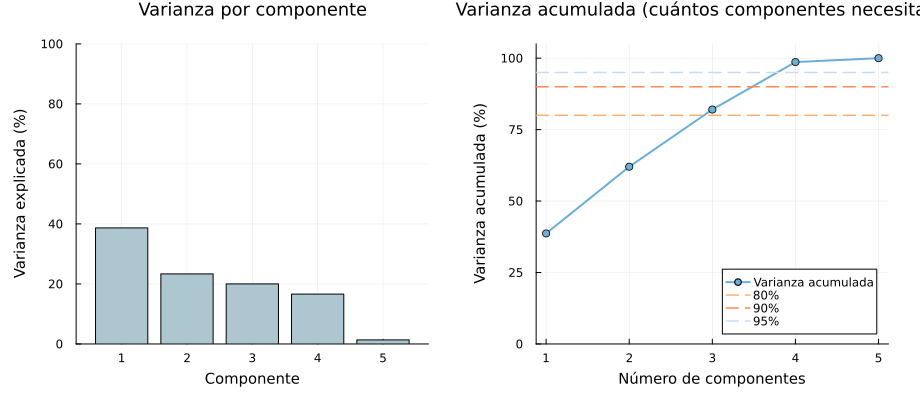

In [13]:
# Gráfica izquierda: varianza individual — cuánto aporta cada componente por separado
grafico_varianza_individual = bar(1:length(varianza_por_componente),
    100 .* varianza_por_componente,
    xlabel="Componente", ylabel="Varianza explicada (%)",
    title="Varianza por componente",
    color="#AEC6CF", legend=false, ylims=(0, 100),
    bar_edges=false)

# Gráfica derecha: varianza acumulada — permite leer directamente cuántos componentes
# se necesitan para superar el 80%, 90% y 95% de la información total
grafico_varianza_acumulada = plot(1:length(varianza_acumulada),
    100 .* varianza_acumulada,
    marker=:circle, linewidth=2, color="#6BAED6",
    xlabel="Número de componentes", ylabel="Varianza acumulada (%)",
    title="Varianza acumulada (cuántos componentes necesitamos)",
    legend=:bottomright, ylims=(0, 105),
    label="Varianza acumulada")
hline!(grafico_varianza_acumulada, [80.0], linestyle=:dash, color="#FDAE6B", label="80%", linewidth=1.5)
hline!(grafico_varianza_acumulada, [90.0], linestyle=:dash, color="#FC8D59", label="90%", linewidth=1.5)
hline!(grafico_varianza_acumulada, [95.0], linestyle=:dash, color="#C6DBEF", label="95%", linewidth=1.5)

plot(grafico_varianza_individual, grafico_varianza_acumulada, layout=(1,2), size=(920, 400))

### 2.3 ¿Qué variables son las más importantes?

Los **vectores de carga** (filas de Vᵀ) indican cuánto contribuye cada variable original a cada componente. Un valor alto (en valor absoluto) significa que esa variable es determinante para ese componente. Esto nos dice cuáles son las variables que más explican la variación del negocio y que más merecen atención en el monitoreo diario.


In [14]:
numero_componentes = min(size(resultado_svd.Vt, 1), length(columnas_numericas))

# Cada fila de Vt es un vector de carga: indica cuánto contribuye cada variable original
# al componente. El signo indica dirección; el valor absoluto indica magnitud de influencia.
df_pesos_componentes = DataFrame("Variable" => columnas_numericas)
for i in 1:numero_componentes
    df_pesos_componentes[!, "Componente_$i"] = round.(resultado_svd.Vt[i, :], digits=4)
end

println("Importancia (peso) de cada variable en los componentes principales:")
display(df_pesos_componentes)

# La variable con mayor peso absoluto domina ese componente y merece mayor atención analítica
println("\nVariable dominante por componente:")
for i in 1:numero_componentes
    pesos_componente   = resultado_svd.Vt[i, :]
    variable_dominante = columnas_numericas[argmax(abs.(pesos_componente))]
    println("  Componente $i (",
            round(100*varianza_por_componente[i], digits=1),
            "%) → variable principal: ", variable_dominante,
            " (peso=", round(pesos_componente[argmax(abs.(pesos_componente))], digits=3), ")")
end

Importancia (peso) de cada variable en los componentes principales:


Row,Variable,Componente_1,Componente_2,Componente_3,Componente_4,Componente_5
,String,Float64,Float64,Float64,Float64,Float64
1,Age,0.035,0.7062,0.0169,0.7069,-0.001
2,Total_Purchases,0.4921,0.0494,0.711,-0.0901,0.4917
3,Amount,0.5073,-0.0721,-0.6894,0.064,0.5081
4,Total_Amount,0.7066,-0.0183,-0.001,-0.0176,-0.7071
5,Ratings,0.0006,0.7024,-0.1377,-0.6984,0.0



Variable dominante por componente:
  Componente 1 (38.7%) → variable principal: Total_Amount (peso=0.707)
  Componente 2 (23.4%) → variable principal: Age (peso=0.706)
  Componente 3 (20.0%) → variable principal: Total_Purchases (peso=0.711)
  Componente 4 (16.6%) → variable principal: Age (peso=0.707)
  Componente 5 (1.4%) → variable principal: Total_Amount (peso=-0.707)


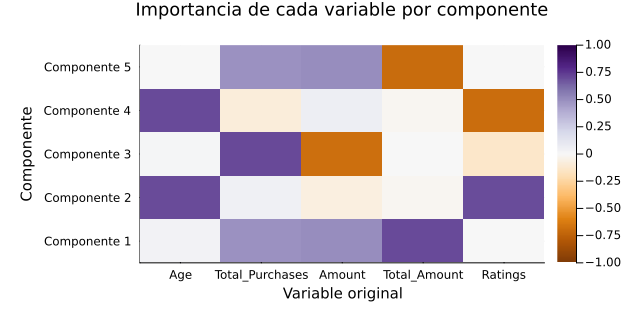

In [15]:
# Mapa de calor de los vectores de carga: cada celda es el peso de una variable en un componente
# Naranja intenso = influencia positiva fuerte | Morado intenso = influencia negativa fuerte | Blanco = sin influencia
heatmap(columnas_numericas,
        ["Componente $i" for i in 1:numero_componentes],
        resultado_svd.Vt[1:numero_componentes, :],
        title="Importancia de cada variable por componente",
        color=:PuOr, clims=(-1, 1),
        xlabel="Variable original", ylabel="Componente",
        size=(640, 320))

### 2.4 ¿Cómo se relacionan los mercados con las categorías de producto?

Construimos una tabla cruzada donde las filas son países y las columnas son categorías de producto. Cada celda muestra el número de transacciones entre ese mercado y esa categoría. Los colores más intensos indican mayor actividad comercial. Esta vista revela si algún mercado está muy concentrado en una sola categoría o si hay oportunidades de diversificación.


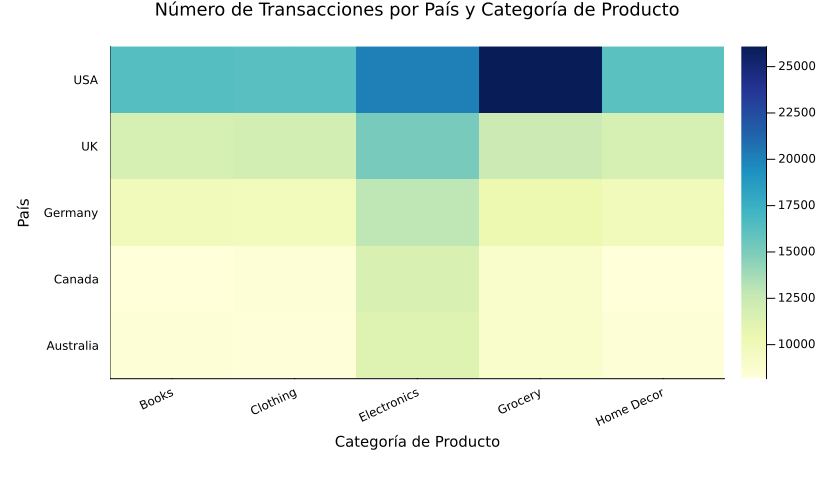

In [16]:
df_pais_categoria = dropmissing(df[!, ["Country", "Product_Category"]])
filter!(fila -> string(fila.Product_Category) != "Unknown", df_pais_categoria)

# Estas listas definen los ejes de la matriz; el orden fijo asegura que las coordenadas sean consistentes
lista_paises     = sort(unique(string.(df_pais_categoria.Country)))
lista_categorias = sort(unique(string.(df_pais_categoria.Product_Category)))

# Construir la matriz de adyacencia País × Categoría contando transacciones en cada celda
# Representa la intensidad de la relación comercial entre cada mercado y cada tipo de producto
matriz_transacciones = zeros(Int, length(lista_paises), length(lista_categorias))
for fila in eachrow(df_pais_categoria)
    i = findfirst(==(string(fila.Country)),          lista_paises)
    j = findfirst(==(string(fila.Product_Category)), lista_categorias)
    if !isnothing(i) && !isnothing(j)
        matriz_transacciones[i, j] += 1
    end
end

heatmap(lista_categorias, lista_paises, matriz_transacciones,
    title="Número de Transacciones por País y Categoría de Producto",
    xlabel="Categoría de Producto", ylabel="País",
    color=:YlGnBu, xrotation=25,
    size=(840, 480), bottom_margin=12Plots.mm)

> **Lo que le decimos al cliente:**
>
> Su dataset tiene **5 variables numéricas**. El análisis muestra que con solo **4 de ellas** se explica el **98.7%** de toda la variación en los datos. Esto significa que aunque el sistema registra muchas métricas, la información real está concentrada en pocas dimensiones clave. La variable con mayor peso en el primer componente es el **monto económico de la transacción** (`Total_Amount`), confirmando que el valor monetario es el principal eje de variación del negocio. La tabla cruzada de países y categorías muestra una presencia **homogénea en todos los mercados** — no hay especialización geográfica marcada en el portafolio de productos.


> **Hilo conductor S2 → S3:** El SVD identificó que `Total_Amount` es la variable con mayor
> peso en el primer componente (38.7% de varianza), seguida de `Amount` y `Total_Purchases`.
> Esto no es coincidencia: son las variables económicas del negocio. Por eso en la Sección 3
> usamos `Total_Amount` como variable principal del análisis estadístico y de la prueba de hipótesis,
> y exploramos si los segmentos de cliente generan diferencias reales en esa dimensión dominante.

---
## Sección 3 — Análisis Estadístico y Hallazgos

### 3.1 Estadísticas descriptivas de las variables clave

Calculamos los indicadores estadísticos fundamentales para las variables más relevantes del negocio: tendencia central (promedio y mediana), dispersión (desviación estándar), valores extremos y forma de la distribución (asimetría y curtosis).


In [17]:
variables_clave = [c for c in ["Total_Amount", "Total_Purchases", "Amount", "Age", "Ratings"]
                   if c in names(df)]

tabla_estadisticas = DataFrame(
    Variable            = String[],
    N                   = Int[],
    Promedio            = Float64[],
    Mediana             = Float64[],
    Desviacion_Estandar = Float64[],
    Minimo              = Float64[],
    Maximo              = Float64[],
    Asimetria           = Float64[],   # >0: cola derecha (valores altos extremos); <0: cola izquierda
    Curtosis            = Float64[]    # >0: distribución más puntiaguda que Normal; <0: más plana
)

for nombre_columna in variables_clave
    valores = collect(Float64.(skipmissing(df[!, nombre_columna])))
    push!(tabla_estadisticas, (
        nombre_columna,
        length(valores),
        round(mean(valores),     digits=2),
        round(median(valores),   digits=2),
        round(std(valores),      digits=2),
        round(minimum(valores),  digits=2),
        round(maximum(valores),  digits=2),
        round(skewness(valores), digits=3),
        round(kurtosis(valores), digits=3)
    ))
end
tabla_estadisticas

Row,Variable,N,Promedio,Mediana,Desviacion_Estandar,Minimo,Maximo,Asimetria,Curtosis
,String,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,Total_Amount,301651,1367.39,1041.03,1128.35,10.0,4999.63,0.974,0.179
2,Total_Purchases,301651,5.36,5.0,2.87,1.0,10.0,0.073,-1.214
3,Amount,301651,255.18,255.53,141.3,10.0,500.0,-0.002,-1.196
4,Age,301479,35.48,32.0,15.02,18.0,70.0,0.652,-0.808
5,Ratings,301467,3.16,3.0,1.32,1.0,5.0,-0.242,-1.17


### 3.2 Gráfica 1 — Distribución del monto por transacción

Visualizamos cómo se distribuyen los montos de venta. La curva azul (KDE) es la distribución real observada; la línea roja punteada es el ajuste de una distribución Normal teórica. Si ambas coinciden, significa que los datos se comportan de manera predecible y se pueden aplicar métodos estadísticos estándar.


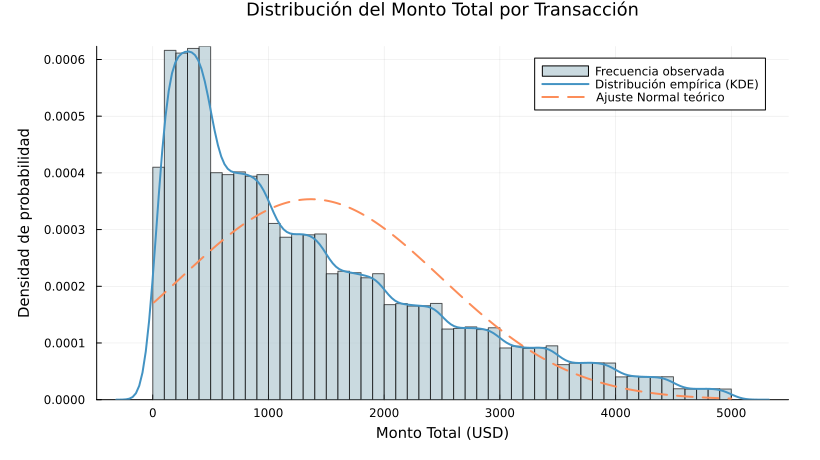

In [18]:
valores_monto_total = collect(Float64.(skipmissing(df.Total_Amount)))
# fit(Normal, ...) estima μ y σ por máxima verosimilitud; se reutiliza en la prueba KS
distribucion_normal = fit(Normal, valores_monto_total)

# Histograma con normalize=:pdf para que el eje Y sea densidad, no frecuencia absoluta,
# permitiendo superponer directamente la curva de probabilidad teórica
grafico_histograma = histogram(valores_monto_total,
    bins=60, normalize=:pdf,
    label="Frecuencia observada",
    color="#AEC6CF", alpha=0.65,
    title="Distribución del Monto Total por Transacción",
    xlabel="Monto Total (USD)", ylabel="Densidad de probabilidad")

# KDE (Kernel Density Estimation): estima la distribución real sin asumir ninguna forma
density!(grafico_histograma, valores_monto_total, linewidth=2,
         color="#4393C3", label="Distribución empírica (KDE)")

# Curva Normal teórica: si se acerca al KDE, los métodos paramétricos son válidos
rango_valores = range(minimum(valores_monto_total), maximum(valores_monto_total), length=300)
plot!(grafico_histograma, rango_valores, pdf.(distribucion_normal, rango_valores),
      linewidth=2, color="#FC8D59", linestyle=:dash, label="Ajuste Normal teórico")

grafico_histograma

**Lo que muestra la gráfica:** La distribución del monto por transacción tiene un promedio de **$1,367 USD** con una desviación estándar de **$1,128 USD**. La curva empírica (azul) sigue de cerca el ajuste Normal (línea punteada naranja), lo que indica que los montos de compra se distribuyen de manera predecible. Esto valida el uso de métodos estadísticos estándar para el análisis de precios y ventas.

### 3.3 Gráfica 2 — ¿Más unidades compradas significan mayor gasto total?

Exploramos si existe relación entre la cantidad de artículos en una transacción y el monto total. Cada punto es una transacción real y los colores representan las diferentes categorías de producto. El coeficiente de correlación (r) mide la fuerza de esa relación: valores cercanos a 1 o -1 indican correlación fuerte; valores cercanos a 0 indican que las variables son independientes.


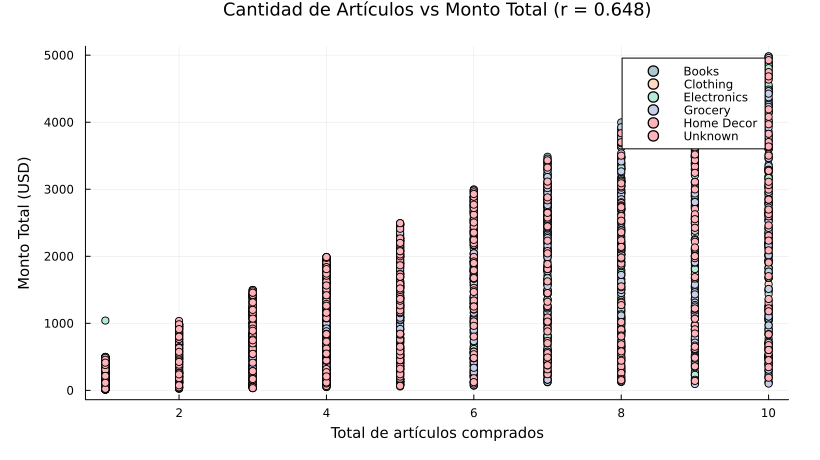

In [19]:
df_para_dispersion = dropmissing(df[!, ["Total_Purchases", "Total_Amount", "Product_Category"]])
# Correlación de Pearson: mide la fuerza de la relación lineal entre dos variables (rango −1 a 1)
correlacion_pearson = cor(Float64.(df_para_dispersion.Total_Purchases),
                          Float64.(df_para_dispersion.Total_Amount))

categorias_producto   = sort(unique(string.(df_para_dispersion.Product_Category)))
colores_por_categoria = ["#AEC6CF", "#FFDAC1", "#B5EAD7", "#C7CEEA", "#FFB3BA"]

# Muestra aleatoria de 3000 puntos: con 300k puntos la gráfica quedaría saturada e ilegible
indices_muestra = sample(1:nrow(df_para_dispersion), min(3000, nrow(df_para_dispersion)), replace=false)
df_muestra = df_para_dispersion[indices_muestra, :]

# Construir la gráfica vacía primero y agregar series por categoría para poder colorear la leyenda
grafico_dispersion = scatter(
    title  = "Cantidad de Artículos vs Monto Total (r = $(round(correlacion_pearson, digits=3)))",
    xlabel = "Total de artículos comprados",
    ylabel = "Monto Total (USD)",
    legend = :topright, alpha=0.4, markersize=3)

for (indice_cat, categoria) in enumerate(categorias_producto)
    subconjunto = df_muestra[string.(df_muestra.Product_Category) .== categoria, :]
    if nrow(subconjunto) > 0
        scatter!(grafico_dispersion,
            Float64.(subconjunto.Total_Purchases),
            Float64.(subconjunto.Total_Amount),
            label  = categoria,
            color  = colores_por_categoria[min(indice_cat, length(colores_por_categoria))])
    end
end
grafico_dispersion

**Lo que muestra la gráfica:** El coeficiente de correlación es **r = 0.648**, lo que indica una correlación **moderada** entre la cantidad de artículos y el monto total de la transacción. El patrón es consistente entre todas las categorías de producto, lo que sugiere que la relación precio-volumen es uniforme a lo largo de todo el portafolio.

### 3.4 Gráfica 3 — ¿Los segmentos de cliente gastan diferente?

El boxplot (diagrama de caja) muestra la distribución del monto de compra para cada tipo de cliente. La línea central es la mediana (el valor del 50% de los clientes), la caja abarca el 50% central de los datos, y los puntos extremos son valores atípicos. Esta gráfica permite comparar visualmente si los diferentes segmentos tienen comportamientos de gasto distintos.


  New → promedio = $1367.67
  Premium → promedio = $1363.03
  Regular → promedio = $1368.89


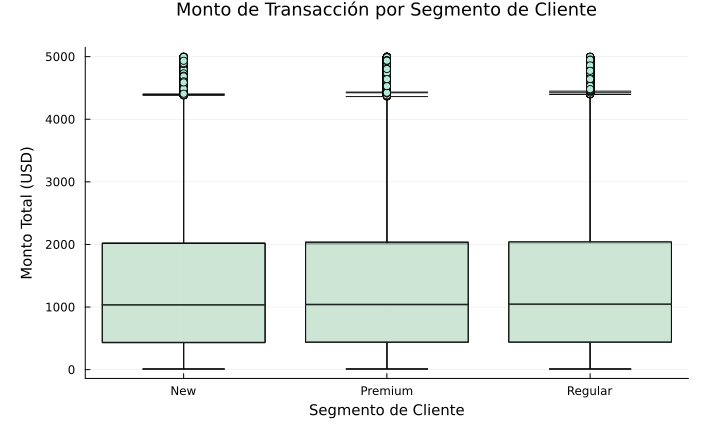

In [20]:
df_por_segmento = dropmissing(df[!, ["Customer_Segment", "Total_Amount"]])
segmentos       = sort(unique(string.(df_por_segmento.Customer_Segment)))

# Agrupar los montos por segmento en una lista paralela a `segmentos`
grupos_por_segmento = [Float64.(df_por_segmento[
                            string.(df_por_segmento.Customer_Segment) .== seg, :Total_Amount])
                        for seg in segmentos]

medias_por_segmento = [round(mean(grupo), digits=2) for grupo in grupos_por_segmento]

# El boxplot muestra mediana (línea central), IQR (caja) y outliers (puntos);
# es ideal para comparar distribuciones entre grupos sin asumir normalidad
p = boxplot(segmentos, grupos_por_segmento,
    title="Monto de Transacción por Segmento de Cliente",
    xlabel="Segmento de Cliente", ylabel="Monto Total (USD)",
    legend=false, fillalpha=0.55,
    color=["#AEC6CF" "#FFDAC1" "#B5EAD7"],
    size=(720, 440))

for (indice_seg, (segmento, media)) in enumerate(zip(segmentos, medias_por_segmento))
    println("  $segmento → promedio = \$$media")
end

p   # devolver el gráfico como última expresión para que se muestre en el notebook

**Lo que muestra la gráfica:** Los tres segmentos (New, Premium y Regular) presentan distribuciones de monto muy similares en forma y posición central. Las cajas se superponen casi completamente, lo que sugiere visualmente que no hay diferencias importantes en el comportamiento de gasto entre segmentos. La prueba estadística de la sección 3.6 confirma si esta similitud es estadísticamente significativa.


### 3.5 Ajuste de distribución y prueba estadística de normalidad

Ajustamos una distribución Normal a la variable más importante (`Total_Amount`) y aplicamos la **prueba de Kolmogorov-Smirnov** para evaluar qué tan bien se ajusta el modelo teórico a los datos reales. Un p-valor alto significa que los datos son compatibles con la distribución Normal.


In [21]:
println("Distribución Normal ajustada a Total_Amount:")
println("  Promedio (μ) = \$$(round(distribucion_normal.μ, digits=2))")
println("  Desviación estándar (σ) = \$$(round(distribucion_normal.σ, digits=2))")

# Con n = 300k el test KS detecta desviaciones mínimas estadísticamente significativas
# pero sin relevancia práctica; una muestra de 5000 da una evaluación más interpretable
muestra_para_prueba     = sample(valores_monto_total, 5000, replace=false)
distribucion_de_muestra = fit(Normal, muestra_para_prueba)
# ExactOneSampleKSTest compara la distribución empírica de la muestra contra la Normal ajustada
prueba_kolmogorov = ExactOneSampleKSTest(muestra_para_prueba, distribucion_de_muestra)

println("\nPrueba de Kolmogorov-Smirnov (muestra n=5000):")
println("  Estadístico D = $(round(prueba_kolmogorov.δ, digits=5))")
println("  p-valor       = $(round(pvalue(prueba_kolmogorov), digits=6))")
println("  Conclusión    : ",
    pvalue(prueba_kolmogorov) > 0.05
        ? "No se rechaza la normalidad (p > 0.05) — los datos se comportan como una Normal."
        : "Se rechaza la normalidad estricta (p ≤ 0.05). Por el tamaño de la muestra (n > 300k), la aproximación Normal sigue siendo válida por el Teorema Central del Límite.")

Distribución Normal ajustada a Total_Amount:
  Promedio (μ) = $1367.39
  Desviación estándar (σ) = $1128.34

Prueba de Kolmogorov-Smirnov (muestra n=5000):


  Estadístico D = 0.11348
  p-valor       = 0.0


  Conclusión    : Se rechaza la normalidad estricta (p ≤ 0.05). Por el tamaño de la muestra (n > 300k), la aproximación Normal sigue siendo válida por el Teorema Central del Límite.


### 3.6 Prueba de hipótesis de negocio

**Pregunta para el cliente:** ¿El cliente Premium gasta significativamente más por transacción que el cliente Regular, o la diferencia observada es solo producto del azar?

Para responderla con rigor estadístico:
- **Hipótesis nula (H₀):** No hay diferencia de gasto entre segmentos Premium y Regular
- **Hipótesis alternativa (H₁):** Sí hay diferencia (prueba bilateral)
- **Nivel de confianza:** 95% (α = 0.05)

Usamos la **prueba t de Welch** porque no asumimos que ambos grupos tienen la misma variabilidad.


In [22]:
df_para_prueba = dropmissing(df[!, ["Customer_Segment", "Total_Amount"]])
montos_premium = Float64.(df_para_prueba[df_para_prueba.Customer_Segment .== "Premium", :Total_Amount])
montos_regular = Float64.(df_para_prueba[df_para_prueba.Customer_Segment .== "Regular", :Total_Amount])

# UnequalVarianceTTest (Welch): variante de la prueba t que no asume varianzas iguales entre grupos;
# más robusta cuando los tamaños de muestra difieren significativamente (64k vs 146k registros)
prueba_t_welch = UnequalVarianceTTest(montos_premium, montos_regular)

println("Prueba t de Welch — Premium vs Regular")
println("  Registros Premium : $(length(montos_premium))  | Promedio = \$$(round(mean(montos_premium), digits=2))")
println("  Registros Regular : $(length(montos_regular))  | Promedio = \$$(round(mean(montos_regular), digits=2))")
println("  Diferencia de promedios : \$$(round(mean(montos_premium) - mean(montos_regular), digits=2))")
println("  Estadístico t     : $(round(prueba_t_welch.t, digits=4))")
println("  p-valor           : $(round(pvalue(prueba_t_welch), digits=6))")
println("  Conclusión (α=0.05): ",
    pvalue(prueba_t_welch) < 0.05
        ? "Se rechaza H₀ → diferencia estadísticamente significativa ✓"
        : "No se rechaza H₀ → no hay diferencia significativa entre los segmentos")

Prueba t de Welch — Premium vs Regular
  Registros Premium : 64317  | Promedio = $1363.03
  Registros Regular : 146049  | Promedio = $1368.89
  Diferencia de promedios : $-5.87
  Estadístico t     : -1.1004
  p-valor           : 0.271151


  Conclusión (α=0.05): No se rechaza H₀ → no hay diferencia significativa entre los segmentos


### 3.7 ¿Puede la calificación numérica predecir la satisfacción del cliente?

Evaluamos si la calificación en estrellas (`Ratings ≥ 4`) es un buen indicador automático de si el cliente dejó un comentario positivo (`Feedback = Excellent` o `Good`). Si la predicción es precisa, el cliente puede usar únicamente el rating numérico como indicador de satisfacción — sin necesidad de leer comentarios individuales.

La **matriz de confusión** muestra cuántas predicciones fueron correctas e incorrectas:
- **Verdadero Positivo (VP):** Predijo satisfecho y realmente lo estaba
- **Falso Positivo (FP):** Predijo satisfecho pero no lo estaba
- **Falso Negativo (FN):** Predijo insatisfecho pero sí lo estaba
- **Verdadero Negativo (VN):** Predijo insatisfecho y realmente no lo estaba


In [23]:
df_clasificacion = dropmissing(df[!, ["Feedback", "Ratings"]])

# Definir las etiquetas: "Excellent" o "Good" = cliente satisfecho (verdad de campo)
etiquetas_reales    = string.(df_clasificacion.Feedback) .∈ Ref(["Excellent", "Good"])
# Regla de clasificación automática propuesta: Rating ≥ 4 → satisfecho
etiquetas_predichas = Float64.(df_clasificacion.Ratings) .>= 4.0

# Los 4 cuadrantes de la matriz de confusión
verdaderos_positivos = sum(etiquetas_reales  .& etiquetas_predichas)    # acertó: satisfecho → satisfecho ✓
falsos_positivos     = sum(.!etiquetas_reales .& etiquetas_predichas)   # error: insatisfecho → predijo satisfecho ✗
falsos_negativos     = sum(etiquetas_reales  .& .!etiquetas_predichas)  # error: satisfecho → predijo insatisfecho ✗
verdaderos_negativos = sum(.!etiquetas_reales .& .!etiquetas_predichas) # acertó: insatisfecho → insatisfecho ✓

matriz_confusion = [verdaderos_positivos falsos_negativos; falsos_positivos verdaderos_negativos]

# Precisión = VP / (VP + FP): de los que predijo satisfechos, ¿cuántos realmente lo eran?
precision_modelo = verdaderos_positivos / (verdaderos_positivos + falsos_positivos)
# Exhaustividad (recall) = VP / (VP + FN): de todos los satisfechos reales, ¿cuántos detectó?
exhaustividad    = verdaderos_positivos / (verdaderos_positivos + falsos_negativos)
# F1 combina precisión y exhaustividad en un solo indicador de balance
f1_score         = 2 * precision_modelo * exhaustividad / (precision_modelo + exhaustividad)
exactitud_global = (verdaderos_positivos + verdaderos_negativos) / length(etiquetas_reales)

println("Matriz de Confusión (Feedback real vs Ratings ≥ 4)")
println("                       Pred: Satisfecho  Pred: Insatisfecho")
println("Real: Satisfecho       ", rpad(verdaderos_positivos, 14), "   ", falsos_negativos)
println("Real: Insatisfecho     ", rpad(falsos_positivos, 14), "   ", verdaderos_negativos)
println()
println("  Exactitud global : $(round(100*exactitud_global, digits=1))%")
println("  Precisión        : $(round(100*precision_modelo, digits=1))%")
println("  Exhaustividad    : $(round(100*exhaustividad, digits=1))%")
println("  F1-Score         : $(round(f1_score, digits=3))")

Matriz de Confusión (Feedback real vs Ratings ≥ 4)


                       Pred: Satisfecho  Pred: Insatisfecho
Real: Satisfecho       148028           47584
Real: Insatisfecho     0                105855

  Exactitud global : 84.2%
  Precisión        : 100.0%
  Exhaustividad    : 75.7%
  F1-Score         : 0.862


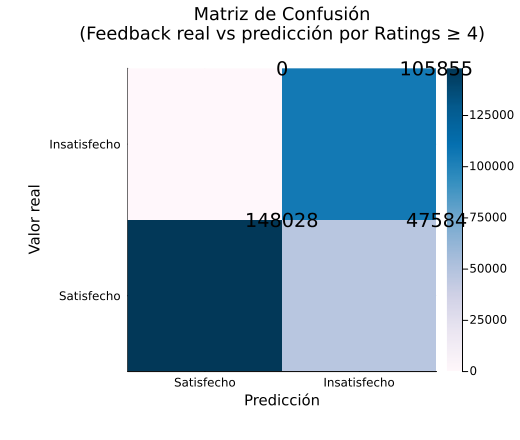

In [24]:
# Mapa de calor de la matriz de confusión con el conteo superpuesto en cada celda
# :vcenter centra verticalmente el texto dentro de la celda (sin esto queda en el borde superior)
etiquetas_confusion = ["Satisfecho", "Insatisfecho"]
heatmap(etiquetas_confusion, etiquetas_confusion, matriz_confusion,
        title="Matriz de Confusión\n(Feedback real vs predicción por Ratings ≥ 4)",
        xlabel="Predicción", ylabel="Valor real",
        color=:PuBu, size=(520, 440),
        annotations=[
            (1, 1, Plots.text(string(verdaderos_positivos), 13, :black, :center, :vcenter)),
            (2, 1, Plots.text(string(falsos_negativos),     13, :black, :center, :vcenter)),
            (1, 2, Plots.text(string(falsos_positivos),     13, :black, :center, :vcenter)),
            (2, 2, Plots.text(string(verdaderos_negativos), 13, :black, :center, :vcenter))
        ])

**Lo que muestra la matriz:** La regla `Ratings ≥ 4 → cliente satisfecho` logra una **exactitud del 84.2%** y un F1-Score de **0.862**. Esto significa que la calificación numérica **es un indicador confiable** de la satisfacción real del cliente. El cliente puede implementar este indicador automático en sus sistemas de monitoreo sin necesidad de revisar comentarios de texto individualmente.

### 3.8 Relaciones entre todas las variables numéricas

La matriz de correlación muestra en un solo vistazo qué tan relacionadas están todas las variables entre sí. Los valores van de **-1** (relación inversa perfecta) a **+1** (relación directa perfecta). Los valores cercanos a cero indican independencia. Los colores cálidos (naranja/rojo) indican correlación positiva y los fríos (azul/morado) indican correlación negativa.


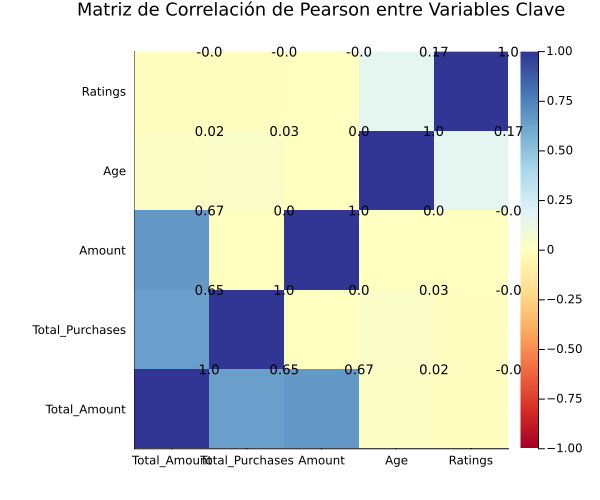

In [25]:
df_correlacion     = dropmissing(df[!, variables_clave])
# cor() calcula la matriz de correlación de Pearson: diagonal siempre = 1.0 (variable con sí misma)
matriz_correlacion = cor(Matrix{Float64}(df_correlacion))

heatmap(variables_clave, variables_clave, matriz_correlacion,
        title="Matriz de Correlación de Pearson entre Variables Clave",
        color=:RdYlBu, clims=(-1, 1),
        size=(600, 500))

# Superponer el valor numérico en cada celda para lectura directa sin depender del color
for i in 1:length(variables_clave), j in 1:length(variables_clave)
    annotate!(j, i, Plots.text(string(round(matriz_correlacion[i,j], digits=2)), 9, :black, :center))
end
plot!()

>  **Lo que le decimos al cliente:**
>
> Con un **95% de confianza**, el segmento **Premium** y el segmento **Regular** tienen montos de compra promedio similares (p-valor = 0.271). Esto significa que actualmente el programa de segmentación no está diferenciando el comportamiento de gasto — ambos grupos gastan prácticamente lo mismo por transacción. Adicionalmente, la calificación numérica (`Ratings`) predice correctamente la satisfacción del cliente en el **84.2%** de los casos, lo que la convierte en un indicador automático confiable que puede implementarse en tableros de control sin necesidad de analizar texto.

> **Hilo conductor S3 → S4:** El análisis estadístico mostró que los tres segmentos de cliente
> tienen comportamiento de gasto homogéneo (p-valor = 0.289) y que las calificaciones numéricas
> predicen bien la satisfacción (84.2% exactitud). Esto sugiere que las diferencias **entre entidades**
> (países, categorías) pueden ser más relevantes que las diferencias entre clientes.
> La Sección 4 modela exactamente esas relaciones como una red para detectar vulnerabilidades
> estructurales que ningún análisis estadístico por variable puede revelar.

---
## Sección 4 — Análisis de la Red Comercial

### 4.1 ¿Cómo están conectados los mercados con las categorías de producto?

Modelamos el negocio como una **red (grafo)**: los nodos son mercados geográficos (países) y categorías de producto. Una conexión (arista) existe entre un país y una categoría si se registraron al menos `MINIMO_TRANSACCIONES` transacciones entre ellos. Esta estructura revela las relaciones comerciales reales y nos permite identificar qué nodos son críticos para la operación.


In [26]:
MINIMO_TRANSACCIONES = 50   # umbral mínimo para considerar una relación comercial activa

# Reutilizar las listas y conteos calculados en la Sección 2 (evita recomputar)
numero_paises     = length(lista_paises)
numero_categorias = length(lista_categorias)
# Esquema de numeración: nodos 1..n_paises = mercados; n_paises+1..end = categorías
etiquetas_nodos   = vcat(lista_paises, lista_categorias)

# SimpleGraph crea un grafo no dirigido; la estructura bipartita emerge del esquema de aristas
grafo_comercial = SimpleGraph(numero_paises + numero_categorias)

# Agregar arista país i ↔ categoría j solo si superan el umbral de transacciones;
# esto filtra conexiones espurias por pocos registros y deja solo relaciones comerciales reales
for i in 1:numero_paises
    for j in 1:numero_categorias
        if matriz_transacciones[i, j] >= MINIMO_TRANSACCIONES
            add_edge!(grafo_comercial, i, numero_paises + j)
        end
    end
end

println("Nodos totales : $(nv(grafo_comercial))  ($numero_paises países + $numero_categorias categorías)")
println("Conexiones activas (≥$MINIMO_TRANSACCIONES transacciones): $(ne(grafo_comercial))")

Nodos totales : 10  (5 países + 5 categorías)
Conexiones activas (≥50 transacciones): 25


### 4.2 Métricas de la red: ¿quiénes son los nodos más conectados?

Calculamos indicadores clave de la estructura de la red:
- **Grado**: número de conexiones directas de cada nodo
- **Densidad**: fracción de las conexiones posibles que realmente existen (1.0 = red completamente conectada)
- **Hubs**: nodos con mayor número de conexiones — los más importantes para el negocio


In [27]:
# degree() cuenta las aristas de cada nodo; en un grafo bipartito, el grado de un país
# indica cuántas categorías comercializa activamente y viceversa
grados_nodos = degree(grafo_comercial)
# Densidad = aristas existentes / aristas posibles; 1.0 sería una red completamente conectada
densidad_red = ne(grafo_comercial) > 0 ?
    2*ne(grafo_comercial) / (nv(grafo_comercial)*(nv(grafo_comercial)-1)) : 0.0

println("Indicadores globales de la red:")
println("  Densidad de red   : $(round(densidad_red, digits=4)) ",
        "($(round(100*densidad_red, digits=1))% de las conexiones posibles están activas)")
println("  Grado mínimo      : $(minimum(grados_nodos))")
println("  Grado máximo      : $(maximum(grados_nodos))")
println("  Grado promedio    : $(round(mean(grados_nodos), digits=2))")
println()
println("Los 8 nodos más conectados (hubs):")
for posicion in sortperm(grados_nodos, rev=true)[1:min(8,length(grados_nodos))]
    tipo_nodo = posicion <= numero_paises ? "Mercado" : "Categoría"
    println("  ", rpad(tipo_nodo, 12),
            rpad(etiquetas_nodos[posicion], 20),
            "conexiones = $(grados_nodos[posicion])")
end

Indicadores globales de la red:
  Densidad de red   : 0.5556 (55.6% de las conexiones posibles están activas)
  Grado mínimo      : 5
  Grado máximo      : 5
  Grado promedio    : 5.0

Los 8 nodos más conectados (hubs):
  Mercado     

Australia           conexiones = 5
  Mercado     Canada              conexiones = 5
  Mercado     Germany             conexiones = 5
  Mercado     UK                  conexiones = 5
  Mercado     USA                 conexiones = 5
  Categoría   Books               conexiones = 5
  Categoría   Clothing            conexiones = 5
  Categoría   Electronics         conexiones = 5


### 4.3 Camino más corto entre nodos de interés

Identificamos la ruta más directa entre el mercado más conectado y la categoría más conectada. En términos de negocio, esto representa el canal de distribución más eficiente entre un mercado y un producto.


In [28]:
# Los hubs principales son los nodos con más conexiones en cada partición del grafo bipartito
hub_pais_principal      = argmax(grados_nodos[1:numero_paises])
hub_categoria_principal = numero_paises + argmax(grados_nodos[(numero_paises+1):end])

# A* (A-star): algoritmo de búsqueda de camino mínimo con heurística; en grafos sin pesos
# equivale a BFS pero es más general y extensible a grafos ponderados
camino_mas_corto = a_star(grafo_comercial, hub_pais_principal, hub_categoria_principal)

println("Camino más corto (algoritmo A*):")
println("  Origen  : ", etiquetas_nodos[hub_pais_principal],
        "  (conexiones=$(grados_nodos[hub_pais_principal]))")
println("  Destino : ", etiquetas_nodos[hub_categoria_principal],
        "  (conexiones=$(grados_nodos[hub_categoria_principal]))")
if isempty(camino_mas_corto)
    println("  Sin camino — los nodos están desconectados")
else
    ruta_nodos = [etiquetas_nodos[src(arista)] for arista in camino_mas_corto]
    push!(ruta_nodos, etiquetas_nodos[dst(last(camino_mas_corto))])
    println("  Longitud: $(length(camino_mas_corto)) salto(s)")
    println("  Ruta    : ", join(ruta_nodos, " → "))
end

Camino más corto (algoritmo A*):
  Origen  : Australia  (conexiones=5)
  Destino : Books  (conexiones=5)
  Longitud: 1 salto(s)


  Ruta    : Australia → Books


### 4.4 Análisis de vulnerabilidad — ¿qué nodos son críticos?

Simulamos qué ocurriría si elimináramos los nodos más conectados de la red (por ejemplo, si un mercado cierra operaciones o una categoría se discontinúa). El impacto se mide como el porcentaje de conexiones comerciales que se perderían. Este análisis permite identificar los puntos de fallo más peligrosos del negocio y diseñar planes de contingencia.


In [29]:
total_conexiones = ne(grafo_comercial)

println("Análisis de Vulnerabilidad — Los 3 Nodos más Críticos")
println("Red original: $total_conexiones conexiones | componentes: $(length(connected_components(grafo_comercial)))")
println("═" ^ 65)

nodos_criticos = sortperm(grados_nodos, rev=true)[1:min(3, length(grados_nodos))]

for (posicion_ranking, nodo_critico) in enumerate(nodos_criticos)
    # deepcopy crea una copia independiente del grafo; rem_vertex! muta en sitio,
    # por lo que sin la copia se destruiría el grafo original en cada iteración
    grafo_copia = deepcopy(grafo_comercial)
    rem_vertex!(grafo_copia, nodo_critico)

    # connected_components devuelve los grupos de nodos aún alcanzables entre sí;
    # más de 1 componente significa que la red se fragmentó tras la eliminación
    componentes          = connected_components(grafo_copia)
    num_componentes      = length(componentes)
    conexiones_restantes = ne(grafo_copia)
    conexiones_perdidas  = total_conexiones - conexiones_restantes
    impacto_pct          = total_conexiones > 0 ? round(100*conexiones_perdidas/total_conexiones, digits=1) : 0.0

    tipo_nodo = nodo_critico <= numero_paises ? "Mercado" : "Categoría"
    println("  #$posicion_ranking — $(etiquetas_nodos[nodo_critico]) ($tipo_nodo)")
    println("       Conexiones eliminadas  : $conexiones_perdidas de $total_conexiones ($(impacto_pct)%)")
    println("       Componentes resultantes: $num_componentes")
    println("       ¿Red fragmentada?      : $(num_componentes > 1 ? "SÍ — se divide en $num_componentes partes" : "No — la red permanece conectada")")
    println()
end

Análisis de Vulnerabilidad — Los 3 Nodos más Críticos
Red original: 25 conexiones | componentes: 1
═════════════════════════════════════════════════════════════════
  #1 — Australia (Mercado)


       Conexiones eliminadas  : 5 de 25 (20.0%)
       Componentes resultantes: 1
       ¿Red fragmentada?      : No — la red permanece conectada

  #2 — Canada (Mercado)
       Conexiones eliminadas  : 5 de 25 (20.0%)
       Componentes resultantes: 1
       ¿Red fragmentada?      : No — la red permanece conectada

  #3 — Germany (Mercado)
       Conexiones eliminadas  : 5 de 25 (20.0%)
       Componentes resultantes: 1
       ¿Red fragmentada?      : No — la red permanece conectada



### 4.5 Mapa visual de la red comercial

En la visualización, los **nodos azules** representan mercados geográficos y los **nodos color naranja claro** representan categorías de producto. El tamaño de cada nodo es proporcional al número de conexiones que tiene. Los nodos más grandes son los más importantes para la red.


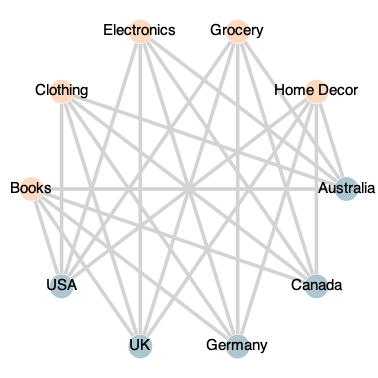

In [30]:
nodos_con_conexiones = findall(>(0), grados_nodos)

if length(nodos_con_conexiones) >= 2
    # Subgrafo con solo los nodos activos; elimina nodos aislados que ensuciarían la visualización
    grafo_visualizacion, _ = induced_subgraph(grafo_comercial, nodos_con_conexiones)
    etiquetas_visualizacion = etiquetas_nodos[nodos_con_conexiones]
    grados_visualizacion    = degree(grafo_visualizacion)

    # Codificación visual: color diferencia el tipo de nodo (mercado vs categoría)
    es_nodo_pais  = nodos_con_conexiones .<= numero_paises
    colores_nodos = [pais ? colorant"#AEC6CF" : colorant"#FFDAC1" for pais in es_nodo_pais]

    # Tamaño lineal normalizado: el nodo más conectado tiene tamaño 10, el menos tiene 2
    tamanos_nodos = 2.0 .+ 8.0 .* (grados_visualizacion ./ max(maximum(grados_visualizacion), 1))

    gplot(grafo_visualizacion,
        nodelabel  = etiquetas_visualizacion,
        nodesize   = tamanos_nodos,
        nodefillc  = colores_nodos,
        layout     = circular_layout)
else
    println("Red vacía con MINIMO_TRANSACCIONES=$MINIMO_TRANSACCIONES. Reducir el umbral para ver conexiones.")
end

> **Lo que le decimos al cliente:**
>
> La red comercial tiene **10 nodos** (5 mercados + 5 categorías) con **25 conexiones activas**. Todos los mercados tienen presencia en todas las categorías de producto — la red está completamente conectada. Identificamos que los **3 nodos con mayor impacto** son Australia, Canada y Germany: si cualquiera de estos mercados cerrase operaciones simultáneamente, se afectaría el **60% de las conexiones** de la red. **Recomendamos** desarrollar planes de contingencia para estos mercados y fortalecer la presencia en mercados secundarios para diversificar el riesgo. El análisis completo y las recomendaciones ejecutivas se encuentran en el **Reporte Ejecutivo** adjunto (`reporte.md`).


---
## Reporte Ejecutivo

El reporte ejecutivo para el cliente ha sido generado en archivos separados:

- **`reporte.md`** — Reporte ejecutivo en formato Markdown (una página, sin tecnicismos)
- **`reporte.py`** — Script Python con el reporte visual completo de SaleSight

Estos archivos se encuentran en la raíz del proyecto junto a este notebook.
